# Exploratory Analysis of Filtering Sources

Characterizes the expression/abundance data sources used for tissue-specific PPI filtering themselves (distributions, coverage, cross-source agreement) — independent of any particular filtering run or downstream module result. Currently covers GTEx (median TPM); PaxDB is included only via the cross-source tissue-clustering comparison in Section 4.

## 1 — Setup

In [1]:
from pathlib import Path

import graph_tool.all as gt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = Path(".").resolve()
NET_DIR   = REPO_ROOT / "data/alzheimer_symbol_runs/alzheimer_run_symbol_threshold_1/input/networks"
EXPR_FILE = REPO_ROOT / "data/expression_by_tissue.gct"
OUT_ROOT  = REPO_ROOT / "sanity_check_outputs"

TISSUE   = "Brain_Hippocampus"
NETWORKS = {
    "iid":    NET_DIR / "iid.human.Symbol.gt",
    "string": NET_DIR / "string.human_links_v12_0_min900.Symbol.gt",
}

OUT_ROOT.mkdir(exist_ok=True)
print("Expression file:", EXPR_FILE)
print("Networks:", {k: v.name for k, v in NETWORKS.items()})


Expression file: /Users/motan/Uni/ba/data/expression_by_tissue.gct
Networks: {'iid': 'iid.human.Symbol.gt', 'string': 'string.human_links_v12_0_min900.Symbol.gt'}


In [2]:
def node_names(gt_path):
    g = gt.load_graph(str(gt_path))
    return {g.vp["name"][v] for v in g.iter_vertices()}

# node sets of the raw, unfiltered networks
original_nodes = {name: node_names(path) for name, path in NETWORKS.items()}
print({k: len(v) for k, v in original_nodes.items()})


{'iid': 18329, 'string': 11927}


## 2 — Load GCT expression data (all tissues)

In [3]:
gct = pd.read_csv(EXPR_FILE, sep="\t", skiprows=2, header=0)
# Description column contains gene symbols; rename for clarity
gct = gct.rename(columns={"Name": "ensembl", "Description": "symbol"})
# strip Ensembl version suffixes
gct["ensembl"] = gct["ensembl"].str.split(".").str[0]

tissue_cols = [c for c in gct.columns if c not in ("ensembl", "symbol")]
# wide matrix (gene symbol x tissue, median TPM), reused by Sections 9-10
gtex_wide = gct.set_index("symbol")[tissue_cols]
print(f"{len(gct):,} genes × {len(tissue_cols)} tissues")
print("Brain tissues:", [t for t in tissue_cols if t.startswith("Brain")])

74,628 genes × 68 tissues
Brain tissues: ['Brain_Amygdala', 'Brain_Anterior_cingulate_cortex_BA24', 'Brain_Caudate_basal_ganglia', 'Brain_Cerebellar_Hemisphere', 'Brain_Cerebellum', 'Brain_Cortex', 'Brain_Frontal_Cortex_BA9', 'Brain_Hippocampus', 'Brain_Hypothalamus', 'Brain_Nucleus_accumbens_basal_ganglia', 'Brain_Putamen_basal_ganglia', 'Brain_Spinal_cord_cervical_c-1', 'Brain_Substantia_nigra']


## 3 — Expression CDF of network nodes, with candidate threshold lines

Where do the network's nodes fall in the GTEx expression distribution for the tissue of interest? Used to sanity-check candidate filtering thresholds before running them.

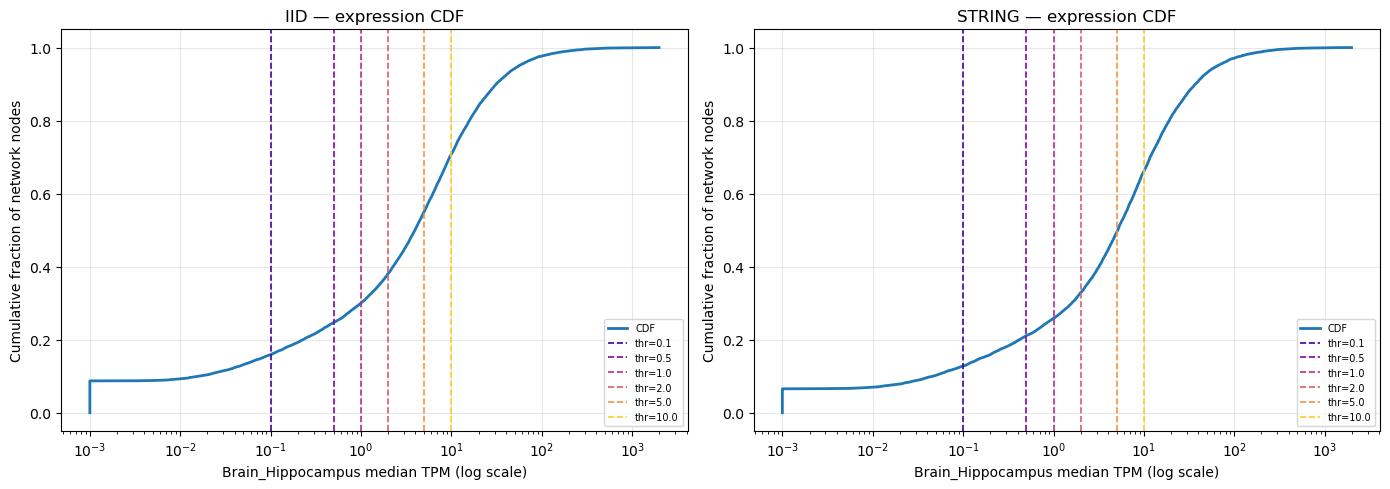

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

THRESHOLDS = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

for ax, (net_name, net_path) in zip(axes, NETWORKS.items()):
    nodes = original_nodes[net_name]
    expr_in_net = gct[gct["symbol"].isin(nodes)][TISSUE].dropna().values
    # clip for visibility; log-scale x after
    expr_clipped = np.clip(expr_in_net, 1e-3, None)
    sorted_expr  = np.sort(expr_clipped)
    cdf          = np.arange(1, len(sorted_expr) + 1) / len(sorted_expr)

    ax.plot(sorted_expr, cdf, lw=2, label="CDF")
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(THRESHOLDS)))
    for thr, col in zip(THRESHOLDS, colors):
        ax.axvline(thr, color=col, linestyle="--", lw=1.2, label=f"thr={thr}")
    ax.set_xscale("log")
    ax.set_xlabel("Brain_Hippocampus median TPM (log scale)")
    ax.set_ylabel("Cumulative fraction of network nodes")
    ax.set_title(f"{net_name.upper()} — expression CDF")
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_ROOT / "expression_cdf.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 — Cross-source comparison: GTEx vs. PaxDB tissue clustering

How well do the two expression/abundance sources agree with each other on tissue identity? Computed on the 10 tissues with an unambiguous 1:1 GTEx ↔ PaxDB name mapping, log2-transformed, using both Spearman correlation and cosine similarity as the similarity metric.

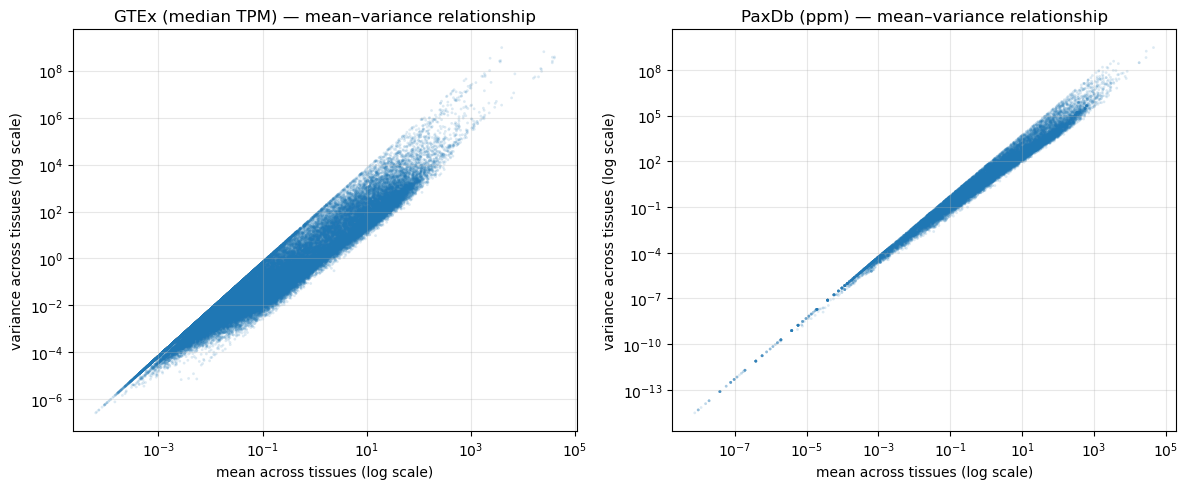

In [5]:
paxdb_mv = pd.read_csv(REPO_ROOT / "data/paxdb_all_tissues.tsv", sep="\t").set_index("id")
# missing entries mean "not detected" (~0 abundance), not "unknown" (see Section 4)
paxdb_mv = paxdb_mv.fillna(0)

gtex_tissue_cols = tissue_cols  # from Section 2
gtex_mean = gct.set_index("symbol")[gtex_tissue_cols].mean(axis=1)
gtex_var  = gct.set_index("symbol")[gtex_tissue_cols].var(axis=1)

paxdb_mean = paxdb_mv.mean(axis=1)
paxdb_var  = paxdb_mv.var(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, mean, var) in zip(
    axes,
    [("GTEx (median TPM)", gtex_mean, gtex_var), ("PaxDb (ppm)", paxdb_mean, paxdb_var)],
):
    mask = (mean > 0) & (var > 0)
    ax.scatter(mean[mask], var[mask], s=4, alpha=0.15, edgecolor="none")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("mean across tissues (log scale)")
    ax.set_ylabel("variance across tissues (log scale)")
    ax.set_title(f"{name} — mean–variance relationship")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_ROOT / "mean_variance_gtex_paxdb.png", dpi=200, bbox_inches="tight")
plt.show()

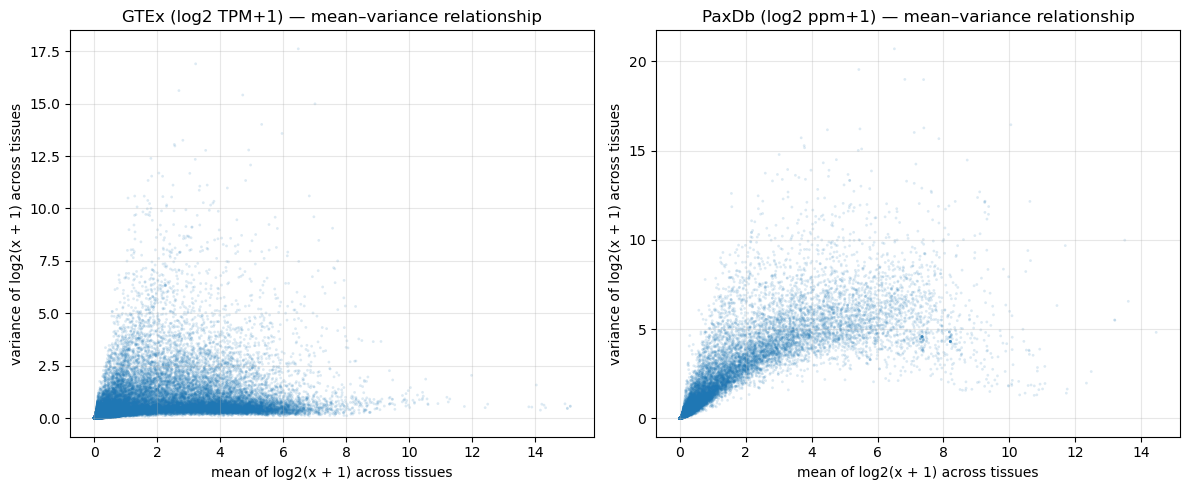

In [6]:
gtex_log = np.log2(gct.set_index("symbol")[gtex_tissue_cols] + 1)
paxdb_log = np.log2(paxdb_mv + 1)

gtex_log_mean = gtex_log.mean(axis=1)
gtex_log_var  = gtex_log.var(axis=1)

paxdb_log_mean = paxdb_log.mean(axis=1)
paxdb_log_var  = paxdb_log.var(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, mean, var) in zip(
    axes,
    [("GTEx (log2 TPM+1)", gtex_log_mean, gtex_log_var), ("PaxDb (log2 ppm+1)", paxdb_log_mean, paxdb_log_var)],
):
    ax.scatter(mean, var, s=4, alpha=0.15, edgecolor="none")
    ax.set_xlabel("mean of log2(x + 1) across tissues")
    ax.set_ylabel("variance of log2(x + 1) across tissues")
    ax.set_title(f"{name} — mean–variance relationship")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_ROOT / "mean_variance_gtex_paxdb_log.png", dpi=150, bbox_inches="tight")
plt.show()

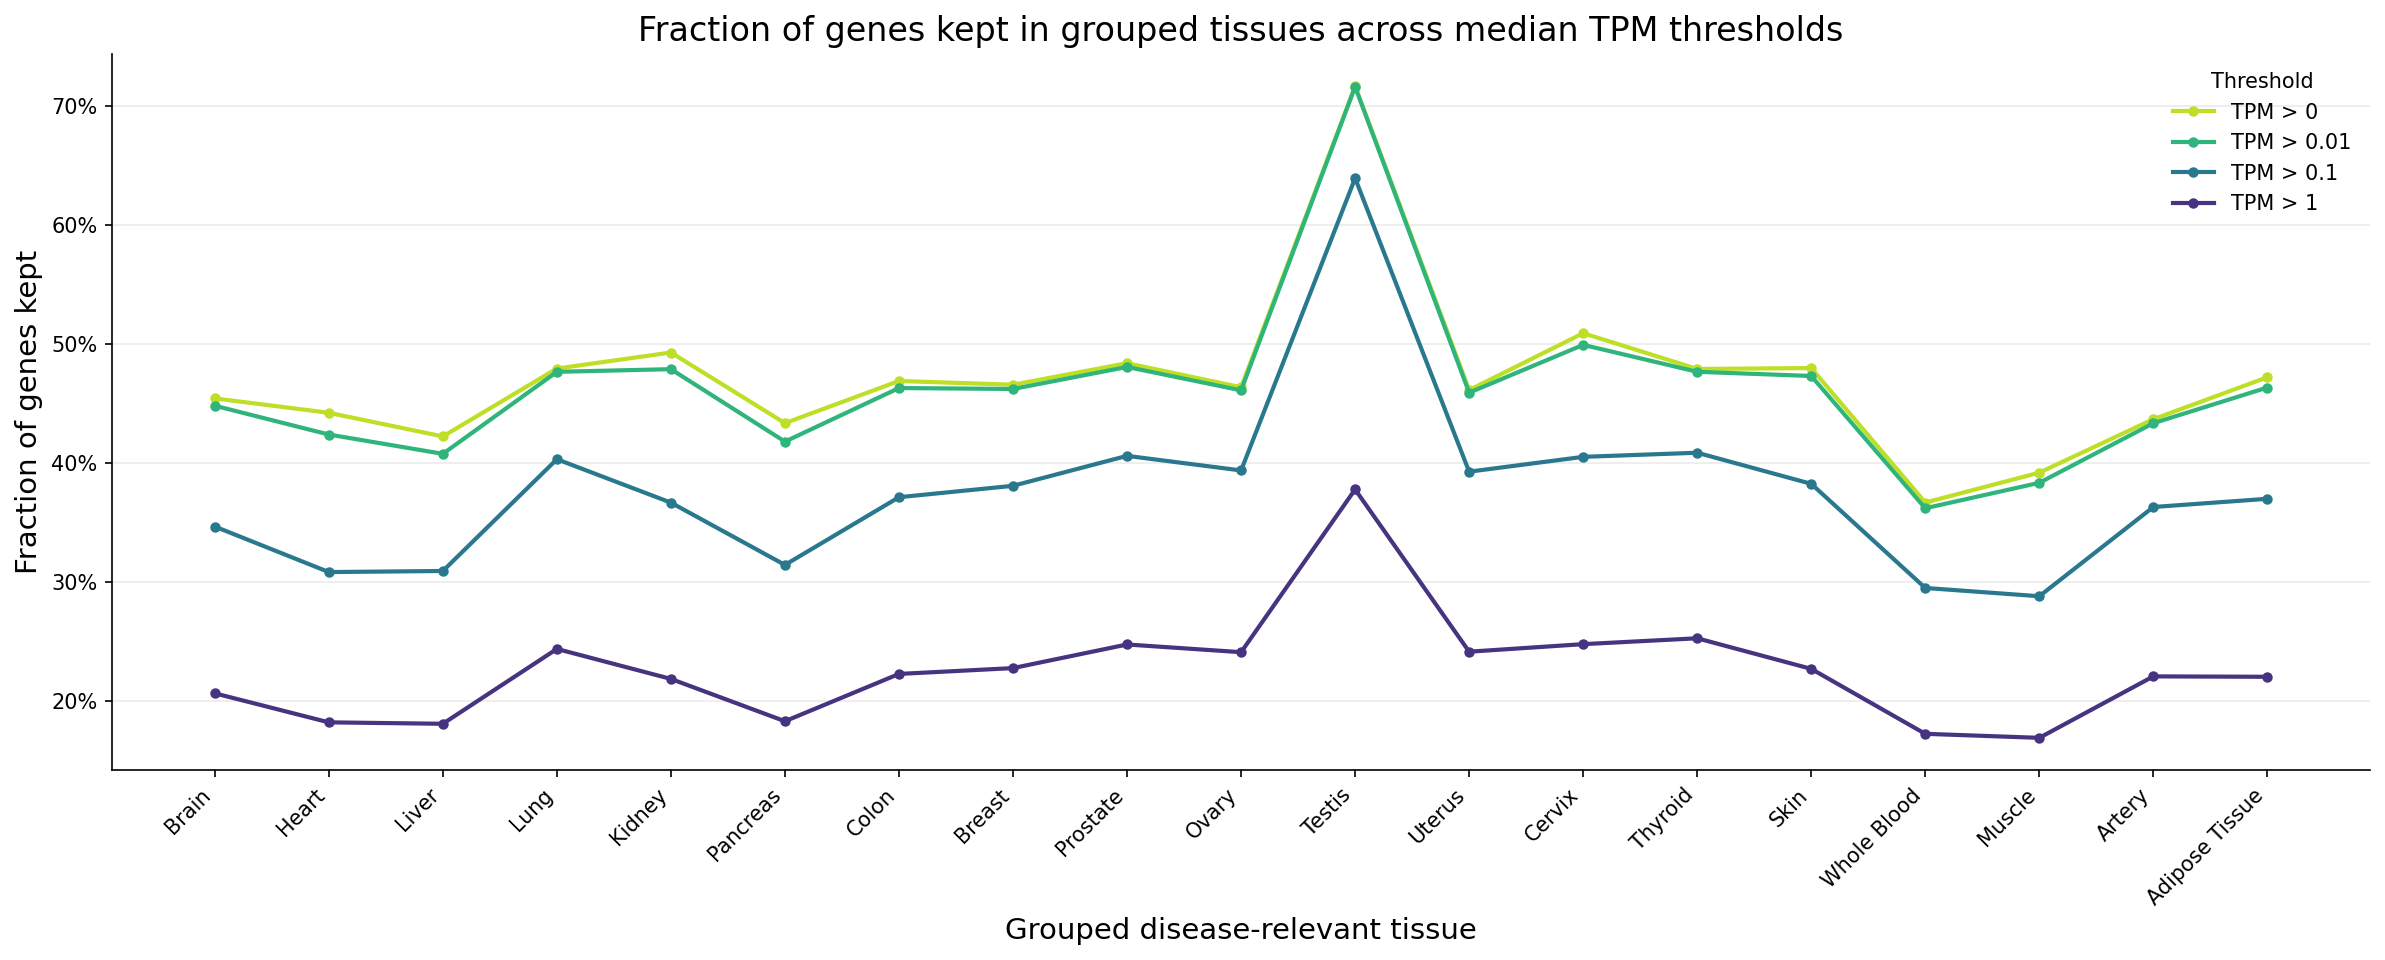

In [7]:
from matplotlib.ticker import PercentFormatter

# Multi-word organs need an explicit mapping; everything else collapses to its
# leading "_"-separated token (e.g. "Kidney_Cortex" -> "Kidney").
_PARENT_TISSUE_OVERRIDES = {
    "Whole_Blood": "Whole Blood",
}

def parent_tissue_name(tissue_col):
    if tissue_col in _PARENT_TISSUE_OVERRIDES:
        return _PARENT_TISSUE_OVERRIDES[tissue_col]
    if tissue_col.startswith("Adipose"):
        return "Adipose Tissue"
    return tissue_col.split("_")[0]

cutoffs = [0, 0.01, 0.1, 1]
total_genes = len(gct)

# Disease-focused tissues: broad organs with many well-characterized tissue-specific diseases.
disease_focused_tissues = [
    "Brain", "Heart", "Liver", "Lung", "Kidney", "Pancreas", "Colon", "Breast",
    "Prostate", "Ovary", "Testis", "Uterus", "Cervix", "Thyroid", "Skin",
    "Whole Blood", "Muscle", "Artery", "Adipose Tissue",
]

tissue_groups_full = pd.Index(gtex_tissue_cols).map(parent_tissue_name)
plot_order = [t for t in disease_focused_tissues if t in tissue_groups_full]

# For each gene, collapse sub-tissues into one parent tissue by median TPM.
grouped_median_tpm = (
    gtex_wide.T.groupby(tissue_groups_full.to_numpy()).median().T[plot_order]
)

fractions_by_cutoff = {
    cutoff: (grouped_median_tpm > cutoff).sum(axis=0) / total_genes
    for cutoff in cutoffs
}

fig, ax = plt.subplots(figsize=(16, 6.5), dpi=150)
colors = plt.cm.viridis_r([0.1 + 0.75 * i / max(len(cutoffs) - 1, 1) for i in range(len(cutoffs))])
x_positions = range(len(plot_order))

for color, cutoff in zip(colors, cutoffs):
    ax.plot(
        x_positions,
        fractions_by_cutoff[cutoff].loc[plot_order].values,
        linewidth=2.0,
        marker="o",
        markersize=4.0,
        color=color,
        label=f"TPM > {cutoff}",
    )

ax.set_xticks(list(x_positions))
ax.set_xticklabels(plot_order, rotation=45, ha="right")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("Grouped disease-relevant tissue", fontsize=14)
ax.set_ylabel("Fraction of genes kept", fontsize=14)
ax.set_title("Fraction of genes kept in grouped tissues across median TPM thresholds", fontsize=16)
ax.legend(title="Threshold", loc="upper right", frameon=False)

plt.tight_layout()
plt.savefig(OUT_ROOT / "gene_fraction_kept_by_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

## 10 — Detected-gene distributions for selected tissues

Fraction of genes detected for a few contrasting tissues plus a merged "Brain" trace (median across all `Brain_*` columns), shown as a per-bin density curve and as a cumulative distribution with candidate threshold lines at TPM = 0.01 / 0.1 / 1.

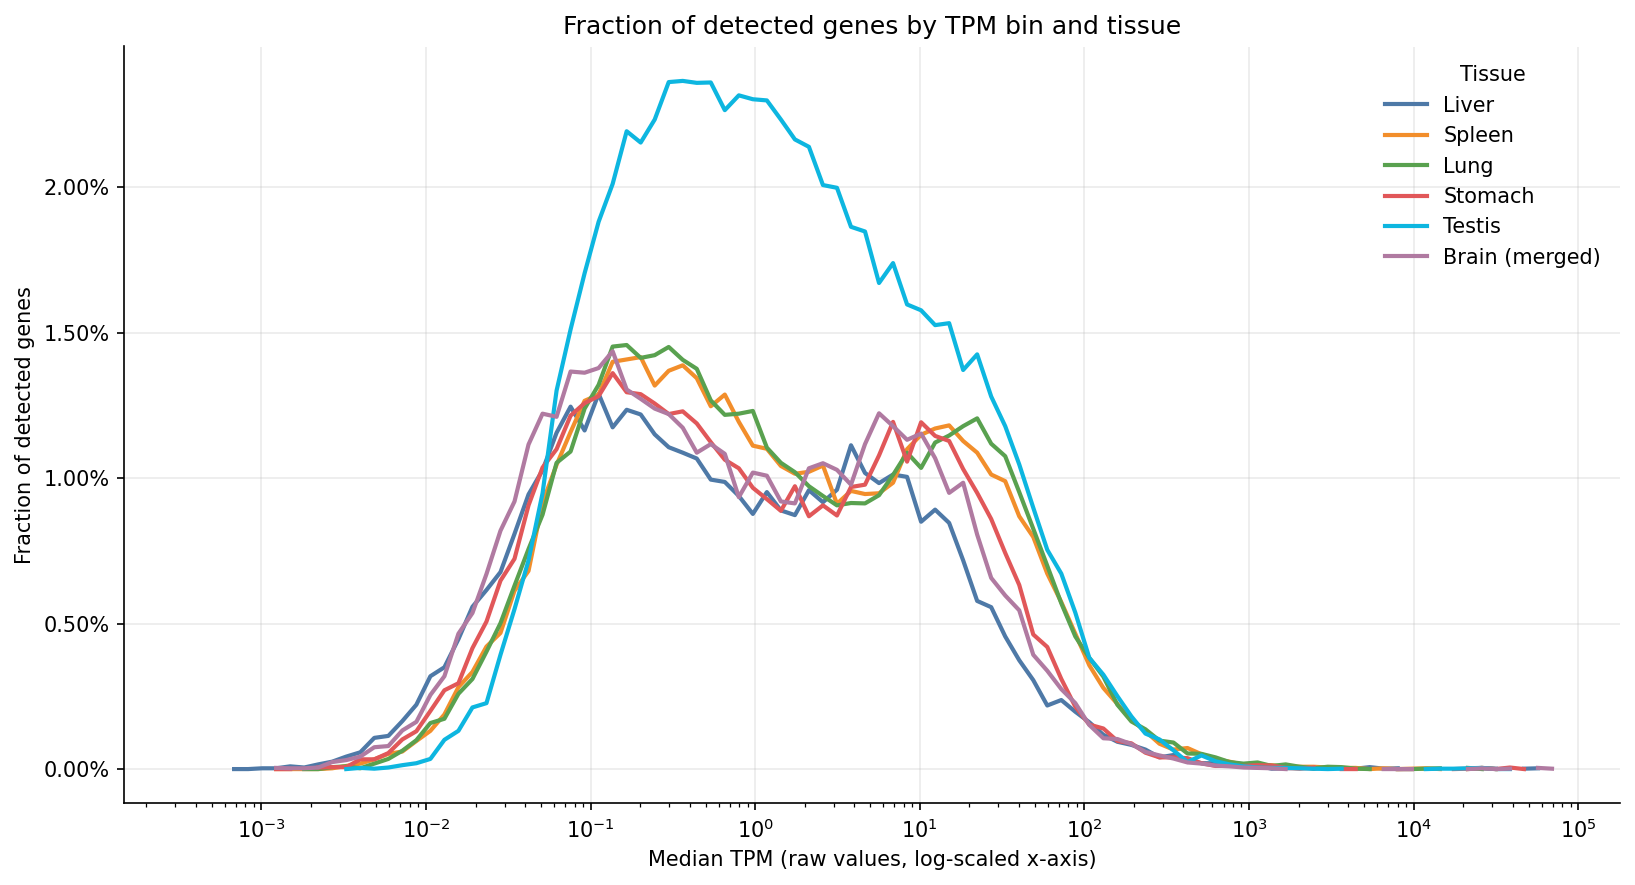

Merged brain tissues: 13 columns


In [8]:
selected_tissues = ["Liver", "Spleen", "Lung", "Stomach", "Testis"]
brain_tissues = [c for c in gtex_tissue_cols if c.startswith("Brain_")]

expression_df = gtex_wide[selected_tissues].copy()
expression_df["Brain (merged)"] = gtex_wide[brain_tissues].median(axis=1)

plot_order = ["Liver", "Spleen", "Lung", "Stomach", "Testis", "Brain (merged)"]
colors = {
    "Liver": "#4e79a7",
    "Spleen": "#f28e2b",
    "Lung": "#59a14f",
    "Stomach": "#e15759",
    "Testis": "#0DB6E0",
    "Brain (merged)": "#b07aa1",
}

# Shared log-spaced bins on raw TPM values (positive only for log-scaled x-axis).
all_values = expression_df[plot_order].to_numpy().ravel()
all_values = all_values[(~np.isnan(all_values)) & (all_values > 0)]
vmin, vmax = all_values.min(), all_values.max()
bin_edges = np.logspace(np.log10(vmin), np.log10(vmax), 100)
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

fig, ax = plt.subplots(figsize=(11, 6), dpi=150)
for tissue in plot_order:
    values = expression_df[tissue].dropna().to_numpy()
    values = values[values > 0]
    counts, _ = np.histogram(values, bins=bin_edges, density=False)
    fractions = counts / total_genes
    fractions = np.where(fractions <= 0, np.nan, fractions)
    ax.plot(bin_centers, fractions, label=tissue, color=colors[tissue], linewidth=2)

ax.set_title("Fraction of detected genes by TPM bin and tissue")
ax.set_xlabel("Median TPM (raw values, log-scaled x-axis)")
ax.set_ylabel("Fraction of detected genes")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xscale("log")
ax.grid(alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Tissue", frameon=False)

plt.tight_layout()
plt.savefig(OUT_ROOT / "gene_detection_by_tpm_bin.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Merged brain tissues: {len(brain_tissues)} columns")

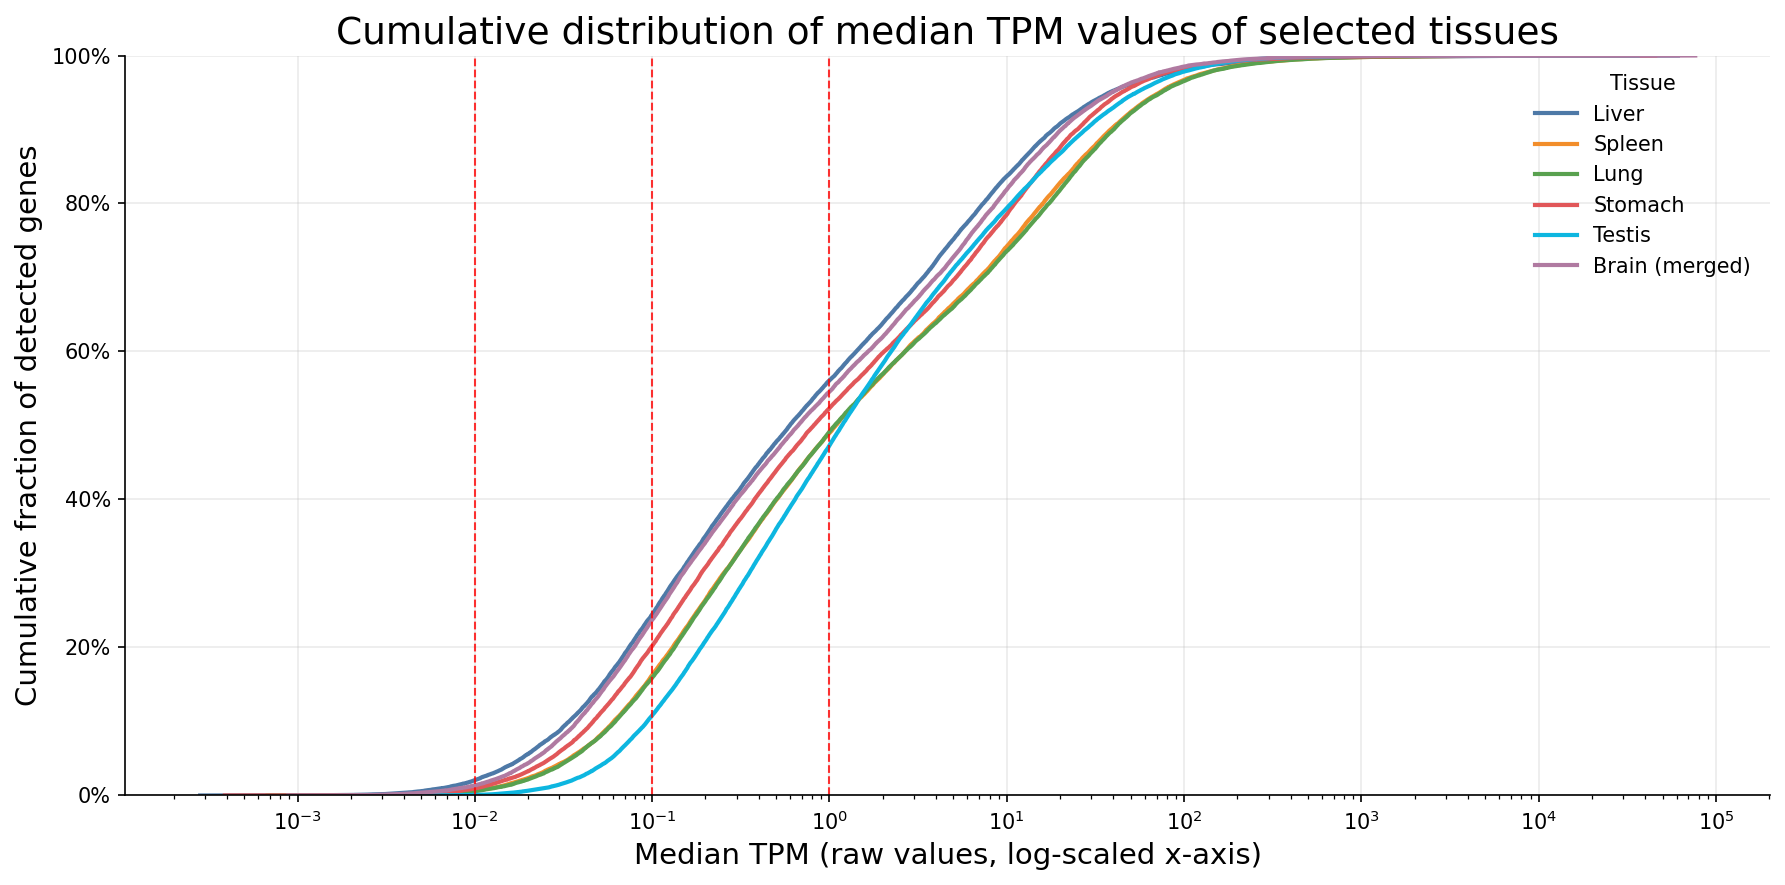

In [9]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

for tissue in plot_order:
    values = expression_df[tissue].dropna().to_numpy()
    values = values[values > 0]
    values_sorted = np.sort(values)
    y = np.arange(1, values_sorted.size + 1) / values_sorted.size
    ax.plot(values_sorted, y, label=tissue, color=colors[tissue], linewidth=2)

ax.set_title("Cumulative distribution of median TPM values of selected tissues", fontsize=18)
ax.set_xlabel("Median TPM (raw values, log-scaled x-axis)", fontsize=14)
ax.set_ylabel("Cumulative fraction of detected genes", fontsize=14)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xscale("log")
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Tissue", frameon=False)

for thr in [0.01, 0.1, 1]:
    ax.axvline(thr, color="red", linestyle="--", linewidth=1, alpha=0.8)

plt.tight_layout()
plt.savefig(OUT_ROOT / "gene_detection_cdf_selected_tissues.png", dpi=150, bbox_inches="tight")
plt.show()

## 11 — Detected-protein distributions for selected tissues (PaxDB)

Same analysis as Section 10, but using PaxDB protein abundance (ppm) instead of GTEx TPM. The merged "Brain (merged)" trace is the median across `ASTROCYTE`, `BRAIN`, `CEREBRAL_CORTEX`, `FRONTAL_CORTEX` — the PaxDB tissues mapped to the "brain" organ group in `data/tissue_uberon_groups.tsv`.

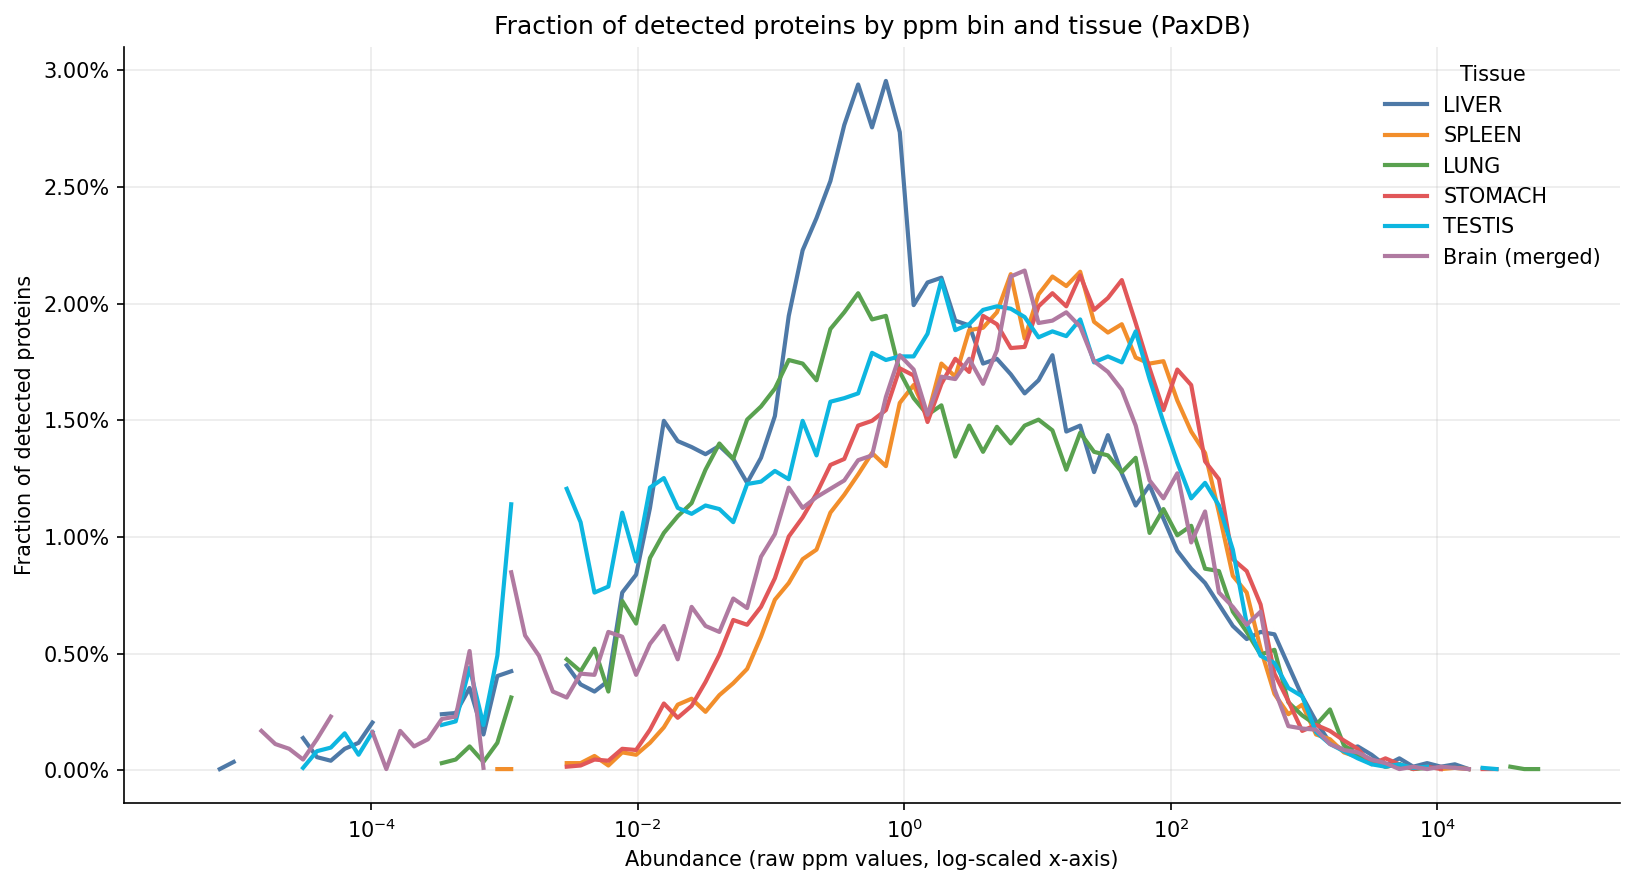

Merged brain tissues: 4 columns


In [10]:
paxdb_selected_tissues = ["LIVER", "SPLEEN", "LUNG", "STOMACH", "TESTIS"]
paxdb_brain_tissues = ["ASTROCYTE", "BRAIN", "CEREBRAL_CORTEX", "FRONTAL_CORTEX"]
total_proteins = len(paxdb_mv)

paxdb_expression_df = paxdb_mv[paxdb_selected_tissues].copy()
paxdb_expression_df["Brain (merged)"] = paxdb_mv[paxdb_brain_tissues].median(axis=1)

paxdb_plot_order = ["LIVER", "SPLEEN", "LUNG", "STOMACH", "TESTIS", "Brain (merged)"]
paxdb_colors = {
    "LIVER": "#4e79a7",
    "SPLEEN": "#f28e2b",
    "LUNG": "#59a14f",
    "STOMACH": "#e15759",
    "TESTIS": "#0DB6E0",
    "Brain (merged)": "#b07aa1",
}

# Shared log-spaced bins on raw ppm values (positive only for log-scaled x-axis).
paxdb_all_values = paxdb_expression_df[paxdb_plot_order].to_numpy().ravel()
paxdb_all_values = paxdb_all_values[(~np.isnan(paxdb_all_values)) & (paxdb_all_values > 0)]
vmin, vmax = paxdb_all_values.min(), paxdb_all_values.max()
paxdb_bin_edges = np.logspace(np.log10(vmin), np.log10(vmax), 100)
paxdb_bin_centers = np.sqrt(paxdb_bin_edges[:-1] * paxdb_bin_edges[1:])

fig, ax = plt.subplots(figsize=(11, 6), dpi=150)
for tissue in paxdb_plot_order:
    values = paxdb_expression_df[tissue].dropna().to_numpy()
    values = values[values > 0]
    counts, _ = np.histogram(values, bins=paxdb_bin_edges, density=False)
    fractions = counts / total_proteins
    fractions = np.where(fractions <= 0, np.nan, fractions)
    ax.plot(paxdb_bin_centers, fractions, label=tissue, color=paxdb_colors[tissue], linewidth=2)

ax.set_title("Fraction of detected proteins by ppm bin and tissue (PaxDB)")
ax.set_xlabel("Abundance (raw ppm values, log-scaled x-axis)")
ax.set_ylabel("Fraction of detected proteins")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xscale("log")
ax.grid(alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Tissue", frameon=False)

plt.tight_layout()
plt.savefig(OUT_ROOT / "paxdb_protein_detection_by_ppm_bin.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Merged brain tissues: {len(paxdb_brain_tissues)} columns")

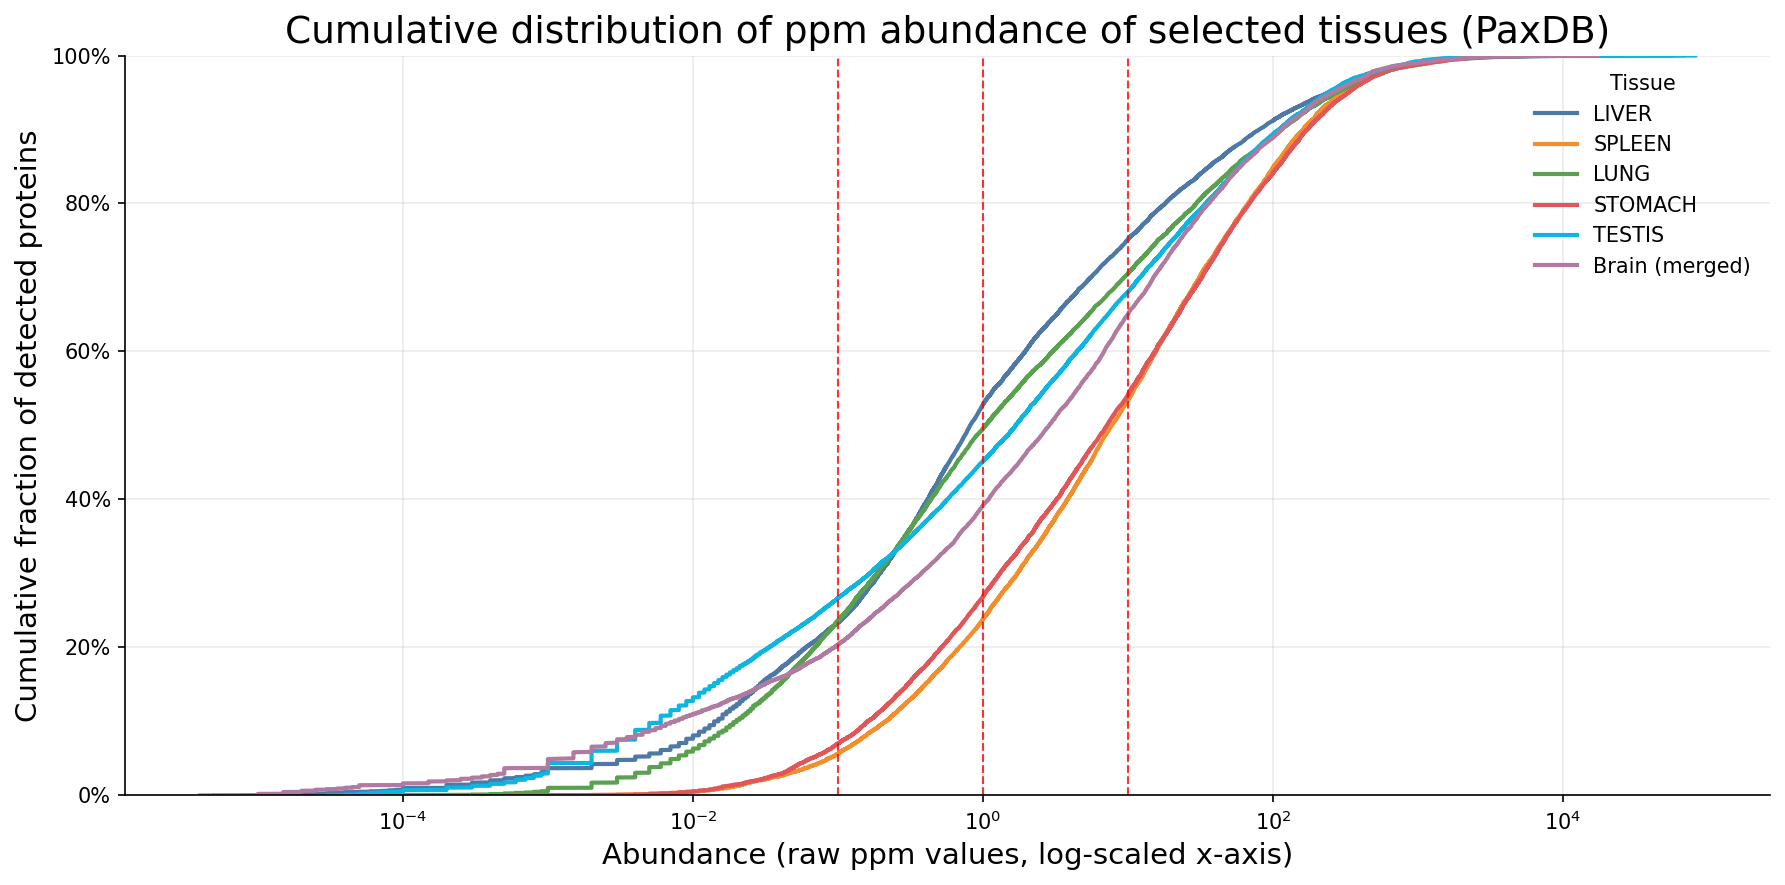

In [11]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

for tissue in paxdb_plot_order:
    values = paxdb_expression_df[tissue].dropna().to_numpy()
    values = values[values > 0]
    values_sorted = np.sort(values)
    y = np.arange(1, values_sorted.size + 1) / values_sorted.size
    ax.plot(values_sorted, y, label=tissue, color=paxdb_colors[tissue], linewidth=2)

ax.set_title("Cumulative distribution of ppm abundance of selected tissues (PaxDB)", fontsize=18)
ax.set_xlabel("Abundance (raw ppm values, log-scaled x-axis)", fontsize=14)
ax.set_ylabel("Cumulative fraction of detected proteins", fontsize=14)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xscale("log")
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Tissue", frameon=False)

for thr in [0.1, 1, 10]:
    ax.axvline(thr, color="red", linestyle="--", linewidth=1, alpha=0.8)

plt.tight_layout()
plt.savefig(OUT_ROOT / "paxdb_protein_detection_cdf_selected_tissues.png", dpi=150, bbox_inches="tight")
plt.show()